# Демо 2. Рабочая область двузвенного манипулятора

*Источник:* П.А. Кручинин. Об освоении пакета MATLAB с использованием практических задач. Здесь задача переведена на Python.

## Постановка задачи

Захват $C$ двузвенного манипулятора (длины звеньев $r_1$, $r_2$) может дотянуться только до точек, достижимых при ограничениях на углы в сочленениях:
$$
|\alpha| \le \alpha_{\max}, \qquad |\beta| \le \beta_{\max}, \qquad |\gamma| \le \gamma_{\max}.
$$
Требуется построить границу этой **рабочей области**.

Задача решается в два этапа:
1. построить замкнутую кривую — границу плоского сечения при $\gamma = 0$;
2. повернуть её вокруг вертикальной оси на углы $\gamma \in [-\gamma_{\max}, \gamma_{\max}]$ и получить пространственную поверхность.

Граница строится по кускам: $\alpha$ пробегает $[-\alpha_{\max}, \alpha_{\max}]$ при $\beta = \beta_{\max}$; затем $\beta$ меняется при $\alpha = \alpha_{\max}$ и т. д. до замыкания кривой. Координаты захвата:
$$
x = r_1\cos\alpha + r_2\cos(\alpha+\beta), \qquad y = r_1\sin\alpha + r_2\sin(\alpha+\beta).
$$

**Что отрабатываем:** формирование векторов из кусков (`np.concatenate`), разворот вектора, двумерную и трёхмерную графику, настройку пределов осей.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def achie(r1, r2, Amax, Bmax, n=100):
    """
    Граница плоского сечения рабочей области (перевод MATLAB-функции achie).

    r1, r2 -- длины звеньев; Amax, Bmax -- предельные углы alpha и beta.
    Возвращает векторы X, Y координат границы (замкнутая кривая).
    """
    Ap = np.linspace(0, Amax, n)
    Bp = np.linspace(0, Bmax, n)
    Am, Bm = Ap[::-1], Bp[::-1]              # fliplr в MATLAB
    A = np.concatenate([-Am, Ap])            # alpha: -Amax ... Amax

    pieces = [
        # beta = +Bmax, alpha от -Amax до Amax
        (r1 * np.cos(A) + r2 * np.cos(A + Bmax), r1 * np.sin(A) + r2 * np.sin(A + Bmax)),
        # alpha = Amax, beta от Bmax до 0
        (r1 * np.cos(Amax) + r2 * np.cos(Amax + Bm), r1 * np.sin(Amax) + r2 * np.sin(Amax + Bm)),
        # звенья вытянуты (beta = 0), alpha от Amax до -Amax
        ((r1 + r2) * np.cos(Am), (r1 + r2) * np.sin(Am)),
        ((r1 + r2) * np.cos(-Ap), (r1 + r2) * np.sin(-Ap)),
        # alpha = -Amax, beta от 0 до -Bmax
        (r1 * np.cos(-Amax) + r2 * np.cos(-Amax - Bp), r1 * np.sin(-Amax) + r2 * np.sin(-Amax - Bp)),
        # beta = -Bmax, alpha от -Amax до Amax
        (r1 * np.cos(A) + r2 * np.cos(A - Bmax), r1 * np.sin(A) + r2 * np.sin(A - Bmax)),
    ]
    # дополнительный участок, если кривые при beta = +-Bmax пересекаются
    if r1 * np.sin(Amax) + r2 * np.sin(Amax - Bmax) < r1 * np.sin(-Amax) + r2 * np.sin(-Amax + Bmax):
        Bk = Amax + np.arcsin(r1 / r2 * np.sin(Amax))
        Bp2 = np.linspace(Bk, Bmax, n)
        Bm2 = Bp2[::-1]
        pieces += [
            (r1 * np.cos(Amax) + r2 * np.cos(Amax - Bm2), r1 * np.sin(Amax) + r2 * np.sin(Amax - Bm2)),
            (r1 * np.cos(-Amax) + r2 * np.cos(-Amax + Bp2), r1 * np.sin(-Amax) + r2 * np.sin(-Amax + Bp2)),
        ]
    X = np.concatenate([p[0] for p in pieces])
    Y = np.concatenate([p[1] for p in pieces])
    return X, Y

## Плоское сечение

Параметры, как в исходной статье: $r_1 = 1$, $r_2 = 1.5$, $\alpha_{\max} = \pi/6$, $\beta_{\max} = \pi/3$. Пределы осей задаются методами `ax.set_xlim`, `ax.set_ylim` (в MATLAB — `set(gca, 'Xlim', ...)`).

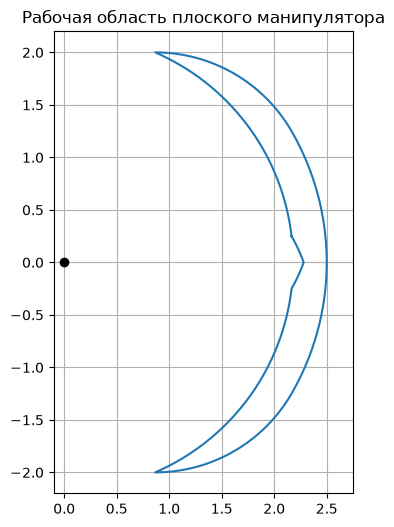

In [2]:
r1, r2 = 1.0, 1.5
Amax, Bmax = np.pi / 6, np.pi / 3
X, Y = achie(r1, r2, Amax, Bmax)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(X, Y)
ax.plot([0], [0], 'ko')                      # основание манипулятора
xmin = min(X.min() - 0.1 * abs(X.min()), -0.1)
ymax = 1.1 * Y.max()
ax.set_xlim(xmin, 1.1 * (r1 + r2))
ax.set_ylim(-ymax, ymax)
ax.set_aspect('equal')                       # одинаковый масштаб осей
ax.set_title(r'Рабочая область плоского манипулятора')
ax.grid(True)
plt.show()

## Пространственная рабочая область

Поворот кривой вокруг оси $Oy$ на угол $\gamma$: $x' = x\cos\gamma$, $z' = x\sin\gamma$, $y' = y$. Для всех пар «точка кривой — угол» координаты вычисляются внешним произведением векторов `np.outer` (в MATLAB — `X'*cos(G)`).

Трёхмерные оси создаются аргументом `projection='3d'`, сетка поверхности рисуется методом `plot_wireframe` (аналог `mesh`), а направление взгляда задаётся методом `view_init(elev, azim)`: углами возвышения и азимута в градусах. В MATLAB направление задавалось вектором, `view([3, -1, -1])`.

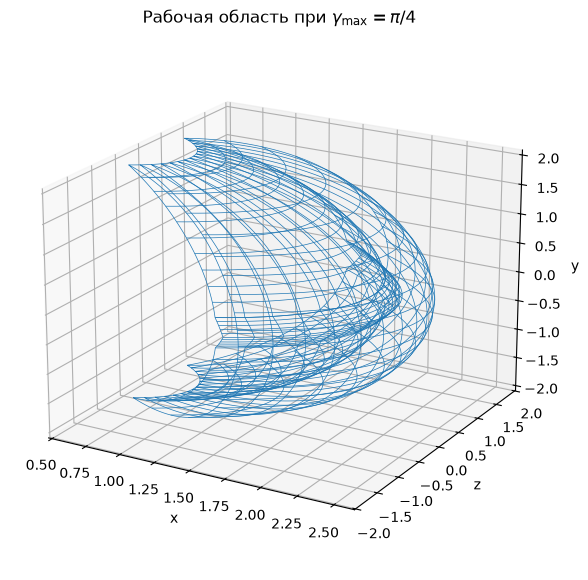

In [3]:
Gmax = np.pi / 4
G = np.linspace(-Gmax, Gmax, 60)

Xp = np.outer(X, np.cos(G))
Yp = np.outer(Y, np.ones_like(G))
Zp = np.outer(X, np.sin(G))

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection='3d')
ax.plot_wireframe(Xp, Zp, Yp, rstride=20, cstride=4, linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel('y')
ax.view_init(elev=20, azim=-60)
ax.set_title(r'Рабочая область при $\gamma_{\max} = \pi/4$')
plt.show()

**Что попробовать:** постройте рабочие области для заданий 1-го блока (например, $1 \le a \le 2$, $-\pi/4 \le \alpha \le \pi/6$); замените `plot_wireframe` на `plot_surface` с прозрачностью `alpha=0.5`; вращайте изображение мышью в интерактивном режиме (`%matplotlib widget`).